# Section 4 — Results, Findings and Analysis
## Predicting Customer Conversion in Digital Marketing: A Multi-Channel Perspective

This notebook implements the methodology described in Section 3. It loads the two
Kaggle datasets, prepares the customer-level data, fits a logistic regression model
(plus tree-based benchmarks), and produces the results, figures, and tables that
support Section 4 of the article.

**Workflow**
1. Setup and data loading
2. Exploratory Data Analysis (EDA)
3. Data preprocessing
4. Train/test split and scaling
5. Logistic regression model
6. Benchmark models (Random Forest, Gradient Boosting)
7. Model evaluation and comparison
8. Interpreting the drivers of conversion (odds ratios)
9. Cross-platform descriptive analysis (supporting dataset)
10. Summary of findings


## Step 1 — Setup and Data Loading

We begin by importing the libraries and loading the **primary dataset**
(`digital_marketing_campaign_dataset.csv`, 8,000 customer records) and the
**supporting dataset** (`Social_Media_Advertising.csv`, campaign-level social data).
Update the file paths if your files sit in a different folder.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)

# Load datasets
df = pd.read_csv("digital_marketing_campaign_dataset.csv")   # primary
social = pd.read_csv("Social_Media_Advertising.csv")         # supporting

print("Primary dataset shape:", df.shape)
print("Supporting dataset shape:", social.shape)
df.head()

Primary dataset shape: (8000, 20)
Supporting dataset shape: (300000, 16)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


## Step 2 — Exploratory Data Analysis (EDA)

Before modelling, we examine the data: its structure, the balance of the target
variable, and how conversion varies across channels and demographics.

In [2]:
# Structure and summary
print("Data types:\n", df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate customers:", df['CustomerID'].duplicated().sum())
df.describe()

Data types:
 CustomerID               int64
Age                      int64
Gender                     str
Income                   int64
CampaignChannel            str
CampaignType               str
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform        str
AdvertisingTool            str
Conversion               int64
dtype: object

Missing values: 0
Duplicate customers: 0


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


Conversion counts:
 Conversion
1    7012
0     988
Name: count, dtype: int64

Conversion percentage:
 Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


/tmp/ipykernel_605/3384017569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Conversion', data=df, palette='Set2')


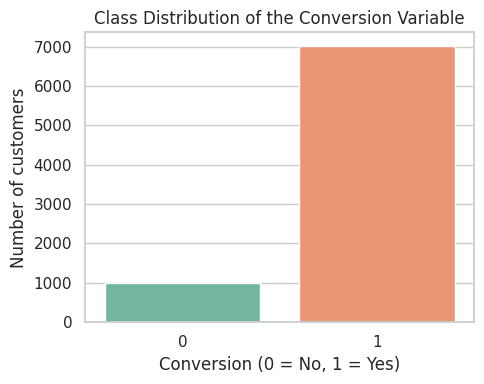

In [3]:
# Target variable balance
conv_counts = df['Conversion'].value_counts()
conv_pct = df['Conversion'].value_counts(normalize=True)*100
print("Conversion counts:\n", conv_counts)
print("\nConversion percentage:\n", conv_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(x='Conversion', data=df, palette='Set2')
plt.title("Class Distribution of the Conversion Variable")
plt.xlabel("Conversion (0 = No, 1 = Yes)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150)
plt.show()

The dataset is **imbalanced**: a large majority of customers converted, while a
small minority did not. This motivates the use of class weighting and the reporting
of recall, precision, F1, and ROC-AUC rather than accuracy alone.

/tmp/ipykernel_605/3485765447.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chan.index, y=chan.values, palette='Set2')


CampaignChannel
Referral        88.31
PPC             88.28
SEO             87.68
Email           87.03
Social Media    86.83
Name: Conversion, dtype: float64


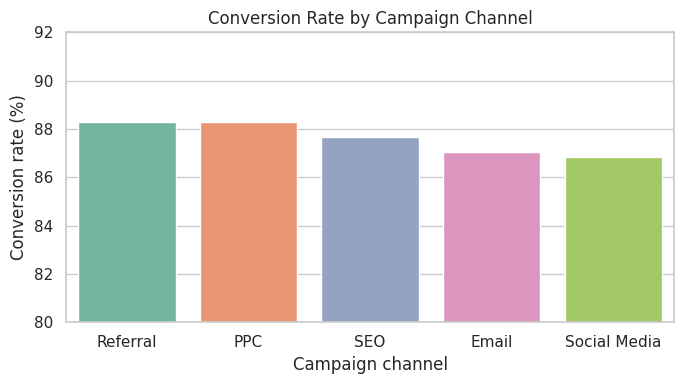

In [4]:
# Conversion rate by campaign channel
chan = (df.groupby('CampaignChannel')['Conversion'].mean()*100).sort_values(ascending=False)
print(chan.round(2))

plt.figure(figsize=(7,4))
sns.barplot(x=chan.index, y=chan.values, palette='Set2')
plt.title("Conversion Rate by Campaign Channel")
plt.ylabel("Conversion rate (%)")
plt.xlabel("Campaign channel")
plt.ylim(80, 92)
plt.tight_layout()
plt.savefig("fig2_conversion_by_channel.png", dpi=150)
plt.show()

/tmp/ipykernel_605/375960176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ctype.index, y=ctype.values, palette='Set3')


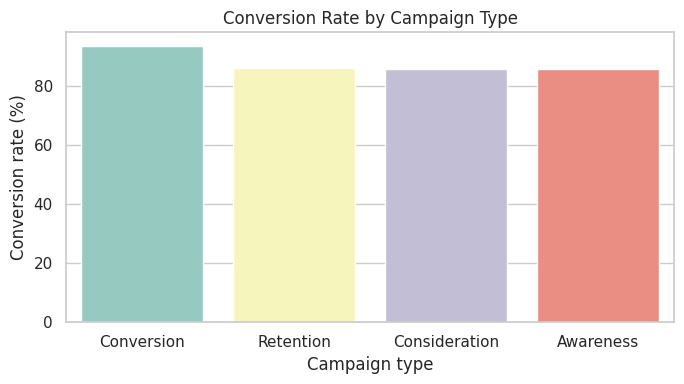

CampaignType
Conversion       93.36
Retention        85.82
Consideration    85.56
Awareness        85.56
Name: Conversion, dtype: float64


In [5]:
# Conversion rate by campaign type
ctype = (df.groupby('CampaignType')['Conversion'].mean()*100).sort_values(ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x=ctype.index, y=ctype.values, palette='Set3')
plt.title("Conversion Rate by Campaign Type")
plt.ylabel("Conversion rate (%)")
plt.xlabel("Campaign type")
plt.tight_layout()
plt.savefig("fig3_conversion_by_type.png", dpi=150)
plt.show()
print(ctype.round(2))

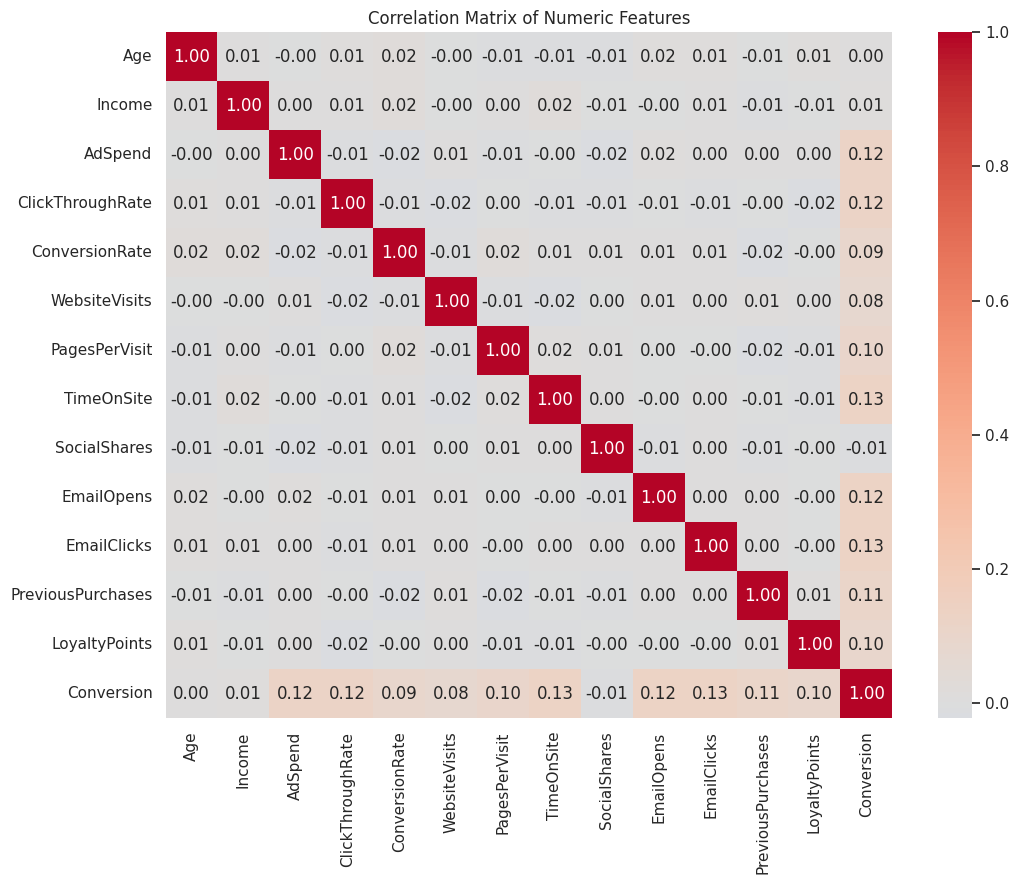

In [6]:
# Correlation heatmap of numeric features
num_cols = ['Age','Income','AdSpend','ClickThroughRate','ConversionRate','WebsiteVisits',
            'PagesPerVisit','TimeOnSite','SocialShares','EmailOpens','EmailClicks',
            'PreviousPurchases','LoyaltyPoints','Conversion']
plt.figure(figsize=(11,9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("fig4_correlation_matrix.png", dpi=150)
plt.show()

**Leakage check.** `ConversionRate` is a continuous field that sounds close to the
target. We verify it is *not* a leaked version of the outcome before keeping it.

In [7]:
# Leakage check on ConversionRate
print("Correlation with target:", round(df['ConversionRate'].corr(df['Conversion']),3))
print(df.groupby('Conversion')['ConversionRate'].mean().round(3))
# Low correlation and overlapping means -> not leakage, safe to retain.

Correlation with target: 0.093
Conversion
0    0.091
1    0.106
Name: ConversionRate, dtype: float64


## Step 3 — Data Preprocessing

We drop identifier and constant columns, separate the target, one-hot encode the
categorical predictors, and prepare the feature matrix.

In [8]:
# Drop identifier and constant columns
df_model = df.drop(columns=['CustomerID','AdvertisingPlatform','AdvertisingTool'])

# Separate target and features
y = df_model['Conversion']
X = df_model.drop(columns=['Conversion'])

# One-hot encode categoricals
X = pd.get_dummies(X, columns=['Gender','CampaignChannel','CampaignType'], drop_first=True)
print("Feature matrix shape after encoding:", X.shape)
X.head()

Feature matrix shape after encoding: (8000, 21)


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,PreviousPurchases,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,4,688,False,False,False,False,True,False,False,False
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,2,3459,True,False,False,False,False,False,False,True
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,8,2337,False,True,False,False,False,False,False,False
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,0,2463,False,True,False,False,False,False,True,False
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,8,4345,False,True,False,False,False,False,True,False


## Step 4 — Train/Test Split and Scaling

We split 80/20, stratifying on the target so the class balance is preserved, then
standardise the numeric features (fitting the scaler on the training set only).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

num_cols_model = ['Age','Income','AdSpend','ClickThroughRate','ConversionRate',
    'WebsiteVisits','PagesPerVisit','TimeOnSite','SocialShares','EmailOpens',
    'EmailClicks','PreviousPurchases','LoyaltyPoints']

scaler = StandardScaler()
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[num_cols_model] = scaler.fit_transform(X_train[num_cols_model])
X_test_s[num_cols_model]  = scaler.transform(X_test[num_cols_model])
print("Training rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])

Training rows: 6400 | Test rows: 1600


## Step 5 — Logistic Regression Model

Logistic regression is our **primary** model because its coefficients are
interpretable. We apply `class_weight='balanced'` to counter the class imbalance.

In [10]:
logit = LogisticRegression(max_iter=1000, class_weight='balanced')
logit.fit(X_train_s, y_train)

y_pred_lr = logit.predict(X_test_s)
y_proba_lr = logit.predict_proba(X_test_s)[:,1]
print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.299     0.732     0.425       198
           1      0.952     0.757     0.844      1402

    accuracy                          0.754      1600
   macro avg      0.626     0.745     0.634      1600
weighted avg      0.872     0.754     0.792      1600



## Step 6 — Benchmark Models

To check how much accuracy we trade for interpretability, we fit two tree-based
benchmarks on the same split.

In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test); y_proba_rf = rf.predict_proba(X_test)[:,1]

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test); y_proba_gb = gb.predict_proba(X_test)[:,1]
print("Benchmark models trained.")

Benchmark models trained.


## Step 7 — Model Evaluation and Comparison

We compile accuracy, precision, recall, F1, and ROC-AUC for all three models into a
single comparison table, then plot ROC curves and the logistic-regression confusion
matrix.

In [12]:
def metrics_row(name, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test,y_pred),3),
        'Precision': round(precision_score(y_test,y_pred),3),
        'Recall': round(recall_score(y_test,y_pred),3),
        'F1': round(f1_score(y_test,y_pred),3),
        'ROC-AUC': round(roc_auc_score(y_test,y_proba),3)
    }

results = pd.DataFrame([
    metrics_row("Logistic Regression", y_pred_lr, y_proba_lr),
    metrics_row("Random Forest", y_pred_rf, y_proba_rf),
    metrics_row("Gradient Boosting", y_pred_gb, y_proba_gb),
])
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.754,0.952,0.757,0.844,0.782
1,Random Forest,0.882,0.884,0.996,0.937,0.807
2,Gradient Boosting,0.910,0.913,0.991,0.951,0.817


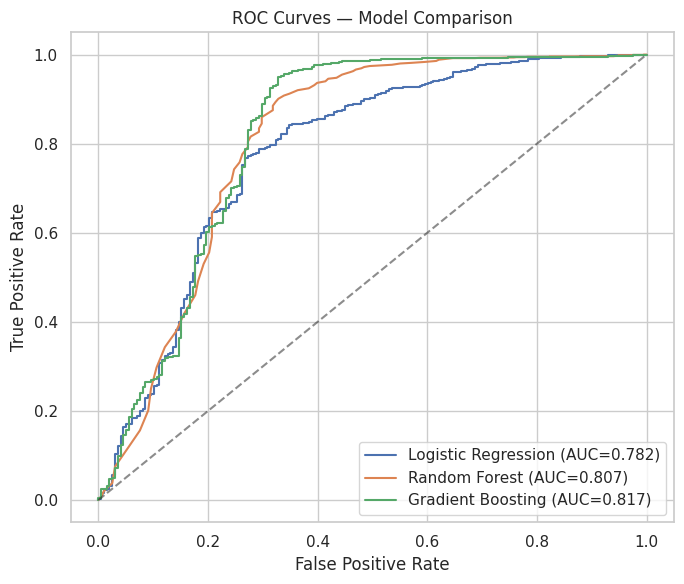

In [13]:
# ROC curves
plt.figure(figsize=(7,6))
for name, proba in [("Logistic Regression",y_proba_lr),
                    ("Random Forest",y_proba_rf),
                    ("Gradient Boosting",y_proba_gb)]:
    fpr,tpr,_ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig("fig5_roc_curves.png", dpi=150); plt.show()

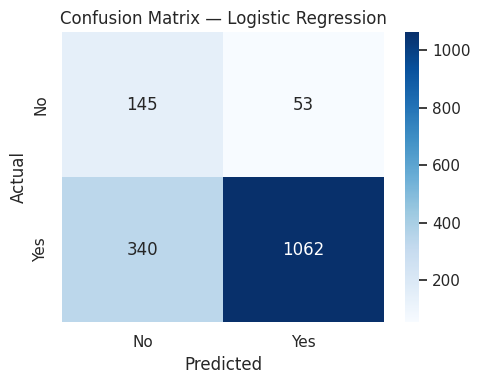

In [14]:
# Confusion matrix for logistic regression
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig("fig6_confusion_lr.png", dpi=150); plt.show()

## Step 8 — Interpreting the Drivers of Conversion

The strength of logistic regression is interpretability. We exponentiate each
coefficient into an **odds ratio**: values above 1 raise the odds of conversion,
values below 1 lower them.

In [15]:
coefs = pd.DataFrame({'Feature':X_train_s.columns, 'Coefficient':logit.coef_[0]})
coefs['Odds Ratio'] = np.exp(coefs['Coefficient'])
coefs = coefs.sort_values('Odds Ratio', ascending=False).reset_index(drop=True)
coefs.round(3)

,Feature,Coefficient,Odds Ratio
0,CampaignType_Conversion,0.732,2.078
1,ClickThroughRate,0.451,1.569
2,TimeOnSite,0.438,1.549
3,EmailClicks,0.416,1.516
4,AdSpend,0.385,1.469
5,EmailOpens,0.382,1.465
6,LoyaltyPoints,0.365,1.440
7,PreviousPurchases,0.361,1.435
8,PagesPerVisit,0.294,1.341
9,CampaignChannel_Referral,0.266,1.305


/tmp/ipykernel_605/3588018872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Feature', x='Odds Ratio', data=plot_df, palette=colors)


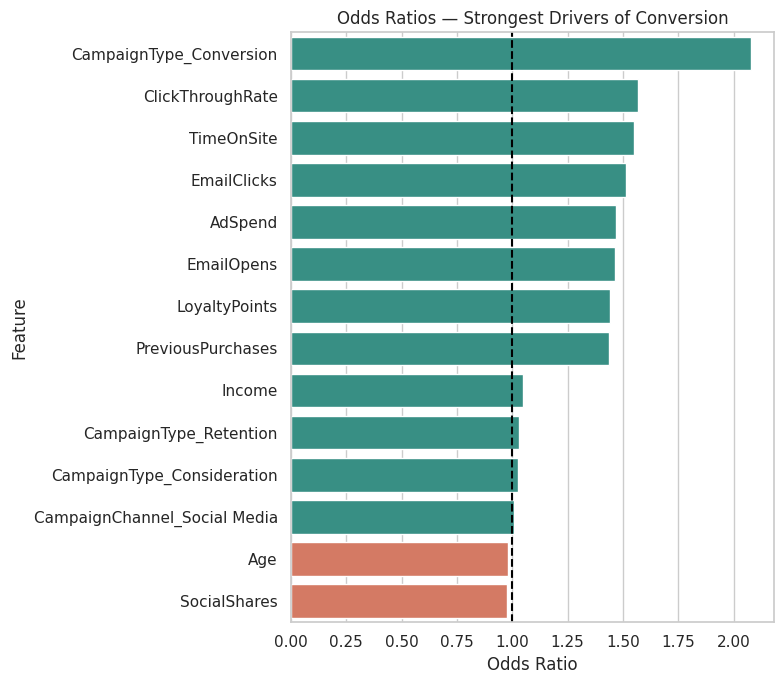

In [16]:
# Visualize top positive and negative drivers
top = coefs.head(8); bottom = coefs.tail(6)
plot_df = pd.concat([top, bottom])
plt.figure(figsize=(8,7))
colors = ['#2a9d8f' if v>1 else '#e76f51' for v in plot_df['Odds Ratio']]
sns.barplot(y='Feature', x='Odds Ratio', data=plot_df, palette=colors)
plt.axvline(1.0, color='black', linestyle='--')
plt.title("Odds Ratios — Strongest Drivers of Conversion")
plt.tight_layout(); plt.savefig("fig7_odds_ratios.png", dpi=150); plt.show()

## Step 9 — Cross-Platform Descriptive Analysis (Supporting Dataset)

The campaign-level social dataset is analysed descriptively (it is **not** merged
with the model). We summarise conversion rate, ROI, and acquisition cost by platform
to provide real-world multi-channel context.

In [17]:
social['Acquisition_Cost'] = (social['Acquisition_Cost']
    .replace(r'[\$,]','',regex=True).astype(float))

platform = social.groupby('Channel_Used').agg(
    Avg_Conversion_Rate=('Conversion_Rate','mean'),
    Avg_ROI=('ROI','mean'),
    Avg_Acquisition_Cost=('Acquisition_Cost','mean'),
    Avg_Engagement=('Engagement_Score','mean')
).round(3).sort_values('Avg_ROI', ascending=False)
platform

,Avg_Conversion_Rate,Avg_ROI,Avg_Acquisition_Cost,Avg_Engagement
Channel_Used,,,,
Instagram,0.08,4.009,7726.253,5.508
Twitter,0.08,4.002,7774.122,5.496
Facebook,0.08,3.987,7745.023,5.478
Pinterest,0.08,0.716,7769.739,1.000


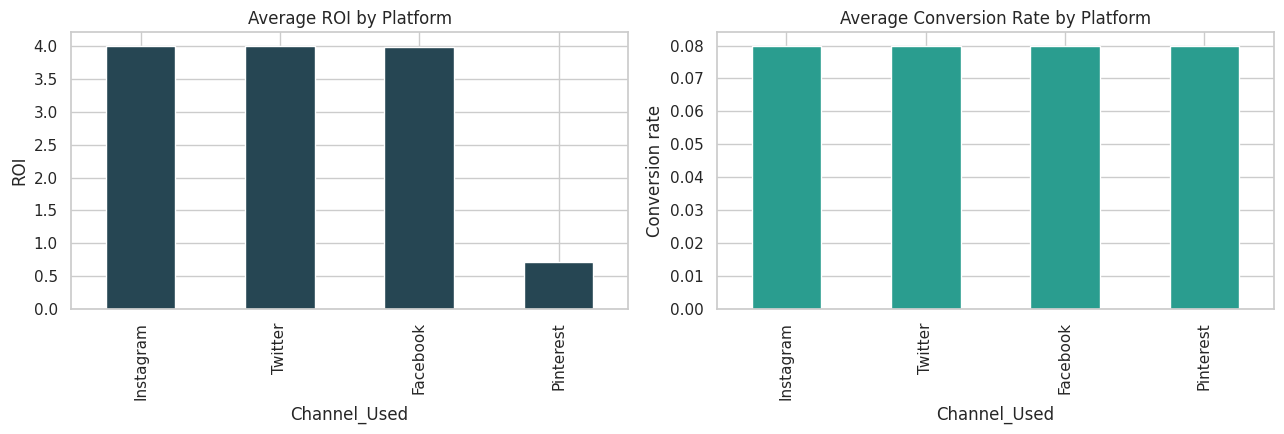

In [18]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
platform['Avg_ROI'].plot(kind='bar', ax=ax[0], color='#264653')
ax[0].set_title("Average ROI by Platform"); ax[0].set_ylabel("ROI")
platform['Avg_Conversion_Rate'].plot(kind='bar', ax=ax[1], color='#2a9d8f')
ax[1].set_title("Average Conversion Rate by Platform"); ax[1].set_ylabel("Conversion rate")
plt.tight_layout(); plt.savefig("fig8_platform_comparison.png", dpi=150); plt.show()

## Step 10 — Summary of Findings

Use the printed comparison table, the odds-ratio table, and the figures above to
write the prose of Section 4. The key threads to report:

- The **class imbalance** and how it shaped metric choice.
- **Logistic regression** performance (esp. recall and ROC-AUC) and what the
  **odds ratios** say about which factors raise or lower conversion odds.
- How the **tree-based benchmarks** compare on accuracy/F1, and the
  accuracy-versus-interpretability trade-off.
- The **cross-platform** descriptive patterns (ROI, conversion, cost by platform)
  as multi-channel context.

All figures are saved as PNG files in the working directory for inclusion in the
article.

In [19]:
# Save key tables for the write-up
results.to_csv("table_model_comparison.csv", index=False)
coefs.to_csv("table_odds_ratios.csv", index=False)
platform.to_csv("table_platform_summary.csv")
print("Saved: table_model_comparison.csv, table_odds_ratios.csv, table_platform_summary.csv")

Saved: table_model_comparison.csv, table_odds_ratios.csv, table_platform_summary.csv
